In [1]:
from multiprocessing import Pool
import subprocess
import yaml
import os
import sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tempfile
import copy
from datetime import datetime
import pandas as pd
from collections import Counter
import numpy as np
import threading
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from joblib import load
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2

In [ ]:
selected_FE = 'clip-vit-large-patch14'  # Example feature extractor, can be changed
input_dir=source_path+f'\\outputs\\online_deep_feature_extraction\\{selected_FE}\\representation_extraction\\extracted_representation'
source_file_train='icdar_train_df_patches_20250716_11370'
source_file_val='icdar_train_df_patches_20250716_120511' #None if using only the training set
source_file_test=None
data_augmentation = True
suffix = '_augmented' if data_augmentation else ''
train_filename = input_dir+f'\\train{suffix}\\{selected_FE}_features_{source_file_train}.csv'
val_filename = input_dir+f'\\val\\{selected_FE}_features_{source_file_val}.csv'

use_external_validation = True
if use_external_validation:
    validation_mode = 'val_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
else:
    validation_mode = '1fold_train_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
selected_classification_head = 'MLPClassifier1'
head_type = 'pytorch'  # 'sklearn' or 'pytorch'
list_of_metrics = ['majority_vote', 'weighted_vote', 'most_probable']

#see from training logs ad set by hand
extra_view=True
extra_integration_mode = 'concat'  # 'concat' or 'add'
aggregation_mode = 'mean'  # 'mean' or 'max'
extra_train_filename = input_dir+'\\extra_view'+f'\\train{suffix}\\{selected_FE}_features_{source_file_train}.csv' if extra_view else None
extra_val_filename = input_dir+'\\extra_view'+f'\\val\\{selected_FE}_features_{source_file_val}.csv' if extra_view else None

In [ ]:
args = script_launching.DotDict(
        data_augmentation=data_augmentation,
        use_external_validation=use_external_validation,
        validation_mode=validation_mode,
        selected_classification_head=selected_classification_head,
        selected_FE=selected_FE,
        head_type=head_type,
        extra_view=extra_view,
        extra_integration_mode=extra_integration_mode,
        aggregation_mode=aggregation_mode,
        #script_mode='standalone'
    )

List of classification heads torch: MLPClassifier1,

In [ ]:
classification_head, val_df = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,validation_mode,train_filename, source_path)
if use_external_validation:
    val_df = pd.read_csv(val_filename) 
    val_df['train'] = 0  # Mark validation data
if extra_view:
    val_df_extra = pd.read_csv(extra_val_filename)
    if not(use_external_validation):
        _, val_df_extra = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,validation_mode,extra_train_filename,source_path)
    val_df = dataframes.merge_dfs(val_df, val_df_extra, mode=extra_integration_mode)
val_df = dataframes.aggregate_dfs(val_df,mode=aggregation_mode)

In [101]:
res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type)

Accuracy for individual patches: 0.673943661971831
Accuracy for majority_vote: 0.7323943661971831
Accuracy for weighted_vote: 0.721830985915493
Accuracy for most_probable: 0.7288732394366197


## descriptive statistics

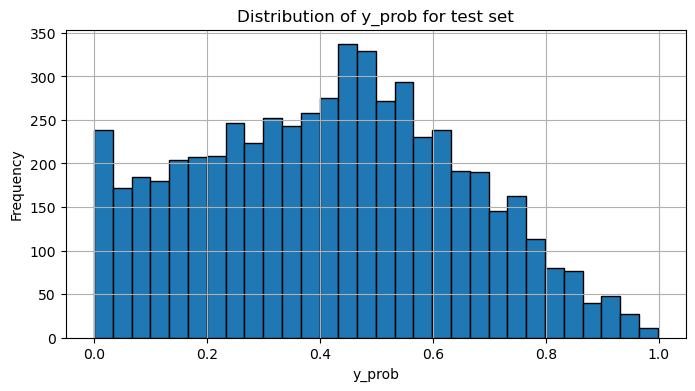

In [102]:
#probability distribution
res_df[res_df['train']==0]['y_prob'].describe()
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
res_df[res_df['train']==0]['y_prob'].hist(bins=30, edgecolor='black')
plt.title('Distribution of y_prob for test set')
plt.xlabel('y_prob')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#descriptive statistics for uncertainty
res_df[res_df['train']==0][[metric+'_uncertainty' for metric in list_of_metrics]].describe()

,majority_vote_uncertainty,weighted_vote_uncertainty,most_probable_uncertainty
count,5680.000000,5680.000000,5680.000000
mean,0.445775,0.685927,0.821560
std,0.312587,0.298836,0.135825
min,0.000000,0.007152,0.476219
25%,0.100000,0.439360,0.725036
50%,0.500000,0.793878,0.837664
75%,0.700000,0.959367,0.940407
max,0.900000,1.000000,0.999753


In [113]:

print(len(res_df[(res_df['train']==0) & (res_df['male']==0)])/len(res_df[res_df['train']==0]))

0.6056338028169014


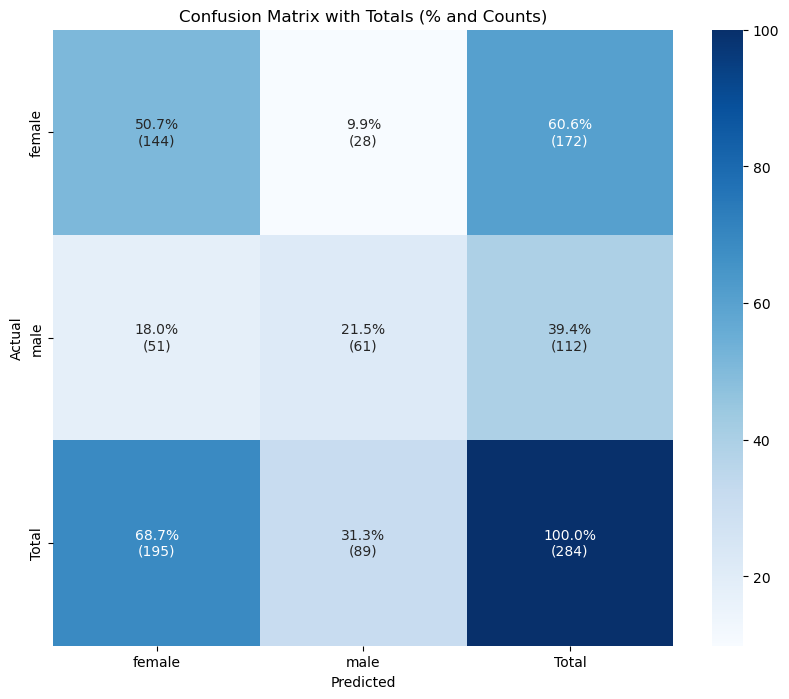

In [121]:
# confusion matrix
selected_metric='weighted_vote'
grouped_res = res_df[res_df['train']==0].groupby('page').first()
true_values = grouped_res['grouped_true']
pred_values = grouped_res[selected_metric]
prob_values = grouped_res[f'{selected_metric}_uncertainty']
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Sample confusion matrix
labels = ['female', 'male']
conf = confusion_matrix(true_values, pred_values)

# Compute row and column totals
row_sums = conf.sum(axis=1, keepdims=True)
col_sums = conf.sum(axis=0, keepdims=True)
total = conf.sum()

# Build extended matrix with totals
conf_ext = np.vstack([conf, col_sums])             # Add totals row
conf_ext = np.hstack([conf_ext, np.append(row_sums, total).reshape(-1, 1)])  # Add totals column

# Convert to percentages
conf_ext_percent = conf_ext / total * 100

# Create labels for display (percentages + raw counts)
annot = np.empty_like(conf_ext).astype(str)
for i in range(conf_ext.shape[0]):
    for j in range(conf_ext.shape[1]):
        count = conf_ext[i, j]
        percent = conf_ext_percent[i, j]
        annot[i, j] = f'{percent:.1f}%\n({int(count)})'

# Define labels with "Total"
xticks = labels + ['Total']
yticks = labels + ['Total']

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(conf_ext_percent, annot=annot, fmt='', cmap='Blues', xticklabels=xticks, yticklabels=yticks)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Totals (% and Counts)")
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(true_values, pred_values, target_names=labels))
# accuracy score
accuracy = accuracy_score(true_values, pred_values)
print(f'Accuracy: {accuracy:.4f}')
#precision = TP/(TP + FP)
#recall = TP/(TP + FN)

              precision    recall  f1-score   support

      female       0.74      0.84      0.78       172
        male       0.69      0.54      0.61       112

    accuracy                           0.72       284
   macro avg       0.71      0.69      0.70       284
weighted avg       0.72      0.72      0.71       284

Accuracy: 0.7218


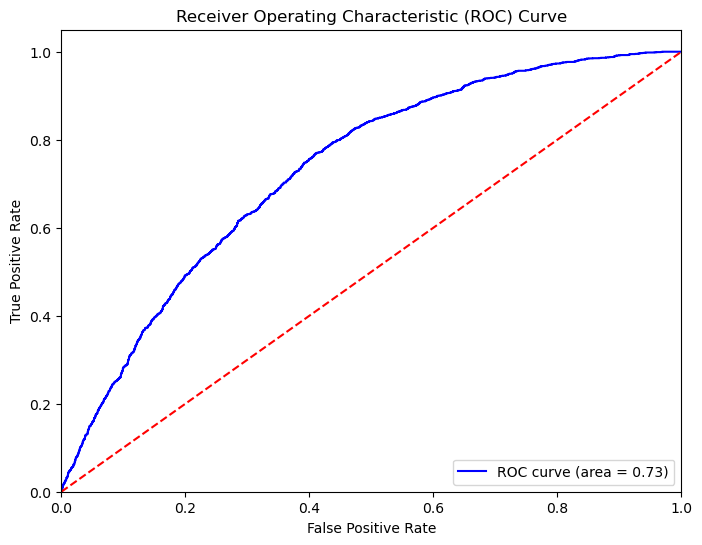

In [123]:
# ROC curve and AUC
from sklearn.metrics import roc_curve, auc
true_values = res_df[res_df['train']==0]['male']
prob_values = res_df[res_df['train']==0]['y_prob']
fpr, tpr, thresholds = roc_curve(true_values, prob_values)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
#TPR=Recall=TP/(TP + FN)
#FPR=FP/(FP + TN)

## select instances

In [ ]:
selected_metric= 'weighted_vote'  # Example metric, can be changed
selected = evaluation_utils.select_instances(res_df, selected_metric)

base_dir=source_path + f'/outputs/online_deep_feature_extraction/{selected_FE}/representation_extraction/'
if head_type == 'sklearn':
    search_dir = base_dir+f'sklearn_model_trained_on_rep/{selected_classification_head}/'
else:
    search_dir = base_dir+f'torch_model_trained_on_rep/{selected_classification_head}/'
selected.to_csv(search_dir+f'selected_instances_{selected_metric}.csv', index=False)
file_IO.save_args(args,search_dir)  # Save the arguments to a file

Number of unique groups for majority_vote: 12
Number of unique groups for weighted_vote: 12
Number of unique groups for most_probable: 12
['weighted_vote_sure', 'weighted_vote_unsure', 'weighted_vote_ok', 'grouped_true']


,weighted_vote_sure,weighted_vote_unsure,weighted_vote_ok,grouped_true
page,,,,
195,0,0,0,0
140,0,0,0,1
32,0,0,1,0
191,0,0,1,1
230,0,1,0,0
179,0,1,0,1
12,0,1,1,0
10,0,1,1,1
19,1,0,0,0


# reload

In [129]:
def reload_modules():
    import importlib
    import utils.data_loading as data_loading
    import utils.visualization as visualization
    import utils.dataframes as dataframes
    import utils.utils_transforms as u_transforms
    import utils.training_utils as training_utils
    import utils.model_utils as model_utils
    import utils.file_IO as file_IO
    import utils.vit_rollout_mod as vit_rollout_mod
    import utils.evaluation_utils as evaluation_utils
    
    importlib.reload(file_IO)
    importlib.reload(data_loading)
    importlib.reload(visualization)
    importlib.reload(dataframes)
    importlib.reload(u_transforms)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(vit_rollout_mod)
    importlib.reload(evaluation_utils)

    return data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils
data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils = reload_modules()